# 🎬 Movie Recommendation System

## Objective

The objective of this project is to build a simple movie
recommendation system that recommends movies based on their genres.

## Technique Used

Content-Based Filtering

## Dataset

MovieLens Dataset

## Tools Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [13]:
!wget --no-check-certificate https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip -q ml-latest-small.zip

--2026-09-05 05:07:15--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
  Issued certificate has expired.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  1.02MB/s    in 0.9s    

2026-09-05 05:07:17 (1.02 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]



In [16]:
!unzip -q ml-latest-small.zip

replace ml-latest-small/links.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [17]:
movies = pd.read_csv("ml-latest-small/movies.csv")

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [19]:
print("Number of movies:", len(movies))
print("Number of columns:", len(movies.columns))

movies.info()

Number of movies: 9742
Number of columns: 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [20]:
ratings = pd.read_csv("ml-latest-small/ratings.csv")
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [21]:
average_ratings = ratings.groupby("movieId")["rating"].mean()
rating_counts = ratings.groupby("movieId")["rating"].count()
movie_stats = pd.DataFrame({
    "average_rating": average_ratings,
    "rating_count": rating_counts
})
movie_stats.head()

,average_rating,rating_count
movieId,,
1,3.920930,215
2,3.431818,110
3,3.259615,52
4,2.357143,7
5,3.071429,49


In [22]:
movies = movies.merge(movie_stats, on="movieId", how="left")
movies.head()

,movieId,title,genres,average_rating,rating_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.920930,215.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.431818,110.0
2,3,Grumpier Old Men (1995),Comedy|Romance,3.259615,52.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.357143,7.0
4,5,Father of the Bride Part II (1995),Comedy,3.071429,49.0


In [23]:
movies["genres"] = movies["genres"].fillna("")
movies["genres"]

,genres
0,Adventure|Animation|Children|Comedy|Fantasy
1,Adventure|Children|Fantasy
2,Comedy|Romance
3,Comedy|Drama|Romance
4,Comedy
...,...
9737,Action|Animation|Comedy|Fantasy
9738,Animation|Comedy|Fantasy
9739,Drama
9740,Action|Animation


In [24]:
tfidf = TfidfVectorizer(token_pattern=r"[^|]+")
tfidf_matrix = tfidf.fit_transform(movies["genres"])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9742, 20)


In [25]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (9742, 9742)


In [26]:
movie_indices = pd.Series(
    movies.index,
    index=movies["title"].str.lower()
).drop_duplicates()
movie_indices.head()

,0
title,
toy story (1995),0
jumanji (1995),1
grumpier old men (1995),2
waiting to exhale (1995),3
father of the bride part ii (1995),4


In [28]:
def recommend_movies(movie_title, number_of_recommendations=10):
    movie_title = movie_title.lower()
    if movie_title not in movie_indices:
        print("Movie not found.")
        print("Please enter the exact movie title.")
        return
    index = movie_indices[movie_title]
    similarity_scores = list(enumerate(cosine_sim[index]))
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    similarity_scores = similarity_scores[1:number_of_recommendations + 1]

    movie_indices_list = [i[0] for i in similarity_scores]

    recommendations = movies.iloc[movie_indices_list][
        ["title", "genres", "average_rating", "rating_count"]
    ].copy()
    recommendations["similarity_score"] = [
        round(i[1], 3) for i in similarity_scores
    ]
    return recommendations

In [29]:
recommend_movies("Toy Story (1995)")

,title,genres,average_rating,rating_count,similarity_score
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,3.244444,45.0,1.0
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,3.860825,97.0,1.0
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,2.222222,9.0,1.0
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,3.716216,37.0,1.0
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,3.871212,132.0,1.0
6194,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,2.500000,1.0,1.0
6486,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,3.023810,21.0,1.0
6948,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,3.000000,1.0,1.0
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,5.000000,1.0,1.0
8219,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,2.500000,1.0,1.0


In [33]:
recommend_movies("Jumanji (1995)")

,title,genres,average_rating,rating_count,similarity_score
53,"Indian in the Cupboard, The (1995)",Adventure|Children|Fantasy,3.235294,34.0,1.0
109,"NeverEnding Story III, The (1994)",Adventure|Children|Fantasy,2.000000,7.0,1.0
767,Escape to Witch Mountain (1975),Adventure|Children|Fantasy,3.055556,9.0,1.0
1514,Darby O'Gill and the Little People (1959),Adventure|Children|Fantasy,2.750000,4.0,1.0
1556,Return to Oz (1985),Adventure|Children|Fantasy,3.000000,6.0,1.0
1617,"NeverEnding Story, The (1984)",Adventure|Children|Fantasy,3.581395,43.0,1.0
1618,"NeverEnding Story II: The Next Chapter, The (1...",Adventure|Children|Fantasy,2.500000,8.0,1.0
1799,Santa Claus: The Movie (1985),Adventure|Children|Fantasy,2.250000,4.0,1.0
3574,Harry Potter and the Sorcerer's Stone (a.k.a. ...,Adventure|Children|Fantasy,3.761682,107.0,1.0
6075,"Chronicles of Narnia: The Lion, the Witch and ...",Adventure|Children|Fantasy,3.443548,62.0,1.0


In [34]:
recommend_movies("Titanic (1997)")

,title,genres,average_rating,rating_count,similarity_score
24,Leaving Las Vegas (1995),Drama|Romance,3.625000,76.0,1.0
27,Persuasion (1995),Drama|Romance,4.227273,11.0,1.0
42,How to Make an American Quilt (1995),Drama|Romance,3.066667,15.0,1.0
45,When Night Is Falling (1995),Drama|Romance,3.000000,1.0,1.0
66,Bed of Roses (1996),Drama|Romance,4.000000,8.0,1.0
75,Once Upon a Time... When We Were Colored (1995),Drama|Romance,3.000000,1.0,1.0
76,Angels and Insects (1995),Drama|Romance,3.857143,7.0,1.0
93,"Bridges of Madison County, The (1995)",Drama|Romance,3.282609,23.0,1.0
115,Up Close and Personal (1996),Drama|Romance,3.500000,16.0,1.0
151,Mad Love (1995),Drama|Romance,1.500000,2.0,1.0


In [41]:
movie_name = input("Enter a movie name: ")
recommend_movies(movie_name)

Enter a movie name: Toy Story (1995)


,title,genres,average_rating,rating_count,similarity_score
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,3.244444,45.0,1.0
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,3.860825,97.0,1.0
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,2.222222,9.0,1.0
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,3.716216,37.0,1.0
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,3.871212,132.0,1.0
6194,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,2.500000,1.0,1.0
6486,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,3.023810,21.0,1.0
6948,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,3.000000,1.0,1.0
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,5.000000,1.0,1.0
8219,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,2.500000,1.0,1.0


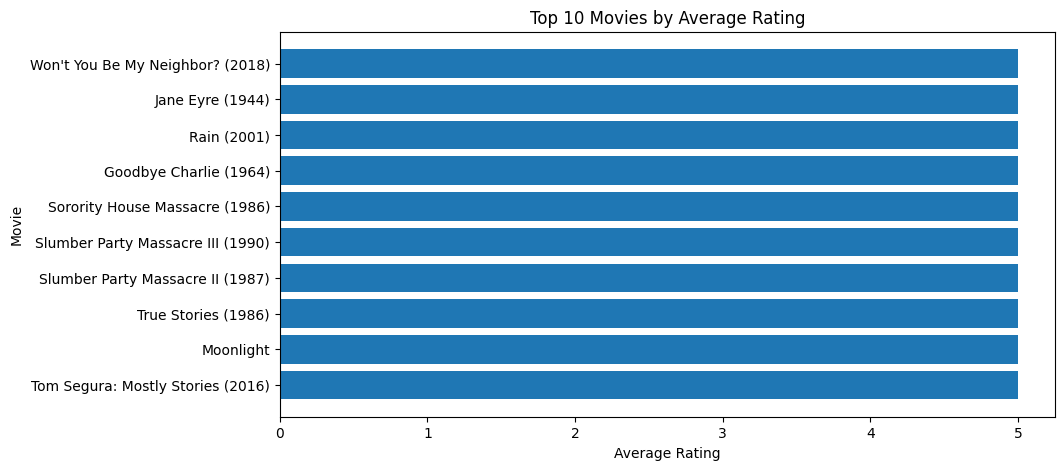

In [42]:
top_movies = movies.sort_values(
    by="average_rating",
    ascending=False
).head(10)
plt.figure(figsize=(10, 5))
plt.barh(
    top_movies["title"],
    top_movies["average_rating"]
)
plt.xlabel("Average Rating")
plt.ylabel("Movie")
plt.title("Top 10 Movies by Average Rating")
plt.gca().invert_yaxis()
plt.show()

In [43]:
popular_movies = movies.sort_values(
    by="rating_count",
    ascending=False
).head(10)
popular_movies[["title", "rating_count", "average_rating"]]

,title,rating_count,average_rating
314,Forrest Gump (1994),329.0,4.164134
277,"Shawshank Redemption, The (1994)",317.0,4.429022
257,Pulp Fiction (1994),307.0,4.197068
510,"Silence of the Lambs, The (1991)",279.0,4.161290
1939,"Matrix, The (1999)",278.0,4.192446
224,Star Wars: Episode IV - A New Hope (1977),251.0,4.231076
418,Jurassic Park (1993),238.0,3.750000
97,Braveheart (1995),237.0,4.031646
507,Terminator 2: Judgment Day (1991),224.0,3.970982
461,Schindler's List (1993),220.0,4.225000


# Conclusion

The Movie Recommendation System successfully recommends movies based on their genre similarity.

TF-IDF was used to convert movie genres into numerical vectors, and Cosine Similarity was used to measure similarity between movies.

The system can be further improved by using user ratings and collaborative filtering techniques.